# Stage 4b - Minimal Weather Features (Ablation)

Variant of Stage 4 with a reduced weather feature set (20 → 5) and no MLflow dependency.

Kept weather features:
- `airTemperature` — primary thermal load driver
- `airTemperature_roll24h` — recent temperature trend
- `airTemperature_roll168h` — weekly seasonal baseline
- `windSpeed` — wind chill effect on heating load
- `temp_dew_spread` — humidity proxy, affects cooling demand

Removed: `seaLvlPressure`, `windDirection`, `wind_u`, `wind_v`, `dewTemperature`, `cooling_degree_c`, `heating_degree_c`, and all their rolling variants.

In [ ]:
import gc
import time
import warnings
from pathlib import Path
import os

import mlflow
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import find_dotenv, load_dotenv
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
load_dotenv(find_dotenv())

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

OUTPUTS_DIR = Path('../../data/processed/anomaly-detection')
RAW_DIR = Path('../../data/raw/data')
FEATURES_PATH = OUTPUTS_DIR / 'stage2_features.parquet'
WEATHER_PATH = RAW_DIR / 'weather' / 'weather.csv'
STAGE4B_MODEL_OUT = OUTPUTS_DIR / 'stage4b_lgbm_model.txt'

TARGET_COL = 'consumption'
RANDOM_STATE = 42

TEST_START = pd.Timestamp('2017-11-01 00:00:00')

MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('stage4b_minimal_weather_tuning')

<Experiment: artifact_location='/mlflow/artifacts/1', creation_time=1781063254838, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781063254838, lifecycle_stage='active', name='stage4b_minimal_weather_tuning', tags={}, trace_location=None, workspace='default'>

---
## 1. Load Stage 2 Feature Matrix

In [2]:
df = pd.read_parquet(FEATURES_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values(['timestamp', 'building_id'], inplace=True)
df.reset_index(drop=True, inplace=True)

df_clean = df.dropna(subset=[TARGET_COL]).copy()

print(f'Raw rows               : {len(df):,}')
print(f'Rows with target        : {len(df_clean):,}')
print(f'Buildings               : {df_clean["building_id"].nunique():,}')
print(f'Date range              : {df_clean["timestamp"].min()} -> {df_clean["timestamp"].max()}')
display(df_clean.head())

Raw rows               : 27,684,432
Rows with target        : 24,635,328
Buildings               : 1,572
Date range              : 2016-01-01 00:00:00 -> 2017-12-31 23:00:00


,timestamp,building_id,consumption,site_id,primaryspaceusage,sqm,lat,lng,timezone,hour,...,delta_1h,delta_24h,pct_change_1h,pct_change_24h,building_mean,building_median,building_std,building_p95,building_p99,consumption_per_sqm
0,2016-01-01,Bear_assembly_Angel,237.8500,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific,0,...,NaN,NaN,NaN,NaN,494.336396,501.2506,172.025938,752.25042,896.274000,0.010754
1,2016-01-01,Bear_assembly_Beatrice,9.0000,Bear,Entertainment/public assembly,2802.0,37.871903,-122.260729,US/Pacific,0,...,NaN,NaN,NaN,NaN,42.962056,37.5000,15.632912,70.25000,75.750000,0.003212
4,2016-01-01,Bear_assembly_Genia,178.7858,Bear,Entertainment/public assembly,24256.1,37.871903,-122.260729,US/Pacific,0,...,NaN,NaN,NaN,NaN,261.089054,234.6070,79.930974,445.79042,524.458104,0.007371
6,2016-01-01,Bear_assembly_Jose,148.5000,Bear,Entertainment/public assembly,3361.2,37.871903,-122.260729,US/Pacific,0,...,NaN,NaN,NaN,NaN,257.140873,248.7500,72.182009,381.20000,424.990000,0.044181
7,2016-01-01,Bear_assembly_Roxy,9.7500,Bear,Entertainment/public assembly,1106.5,37.871903,-122.260729,US/Pacific,0,...,NaN,NaN,NaN,NaN,15.917531,11.7500,11.342586,39.85720,65.500000,0.008812


In [3]:
# rolling_mean_6h: matches Stage 2 shift(1)-then-rolling convention
df_clean.sort_values(['building_id', 'timestamp'], inplace=True)
df_clean['rolling_mean_6h'] = (
    df_clean.groupby('building_id')['consumption']
    .transform(lambda s: s.shift(1).rolling(6, min_periods=1).mean())
    .astype('float32')
)
df_clean.sort_values(['timestamp', 'building_id'], inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'rolling_mean_6h missing rate: {df_clean["rolling_mean_6h"].isna().mean():.4f}')

rolling_mean_6h missing rate: 0.0001


---
## 2. Weather Feature Join

In [4]:
def load_weather_features(path: Path) -> tuple[pd.DataFrame, list[str]]:
    weather = pd.read_csv(path)
    weather['timestamp'] = pd.to_datetime(weather['timestamp'])
    weather.sort_values(['site_id', 'timestamp'], inplace=True)
    weather.reset_index(drop=True, inplace=True)

    for col in ['airTemperature', 'dewTemperature', 'windSpeed']:
        if col in weather.columns:
            weather[col] = pd.to_numeric(weather[col], errors='coerce')

    if {'airTemperature', 'dewTemperature'}.issubset(weather.columns):
        weather['temp_dew_spread'] = weather['airTemperature'] - weather['dewTemperature']

    grp = weather.groupby('site_id', sort=False)['airTemperature']
    weather['airTemperature_roll24h'] = grp.transform(lambda s: s.rolling(24, min_periods=1).mean())
    weather['airTemperature_roll168h'] = grp.transform(lambda s: s.rolling(168, min_periods=1).mean())

    weather_feature_cols = [
        c for c in ['airTemperature', 'windSpeed', 'temp_dew_spread', 'airTemperature_roll24h', 'airTemperature_roll168h']
        if c in weather.columns
    ]
    return weather[['timestamp', 'site_id'] + weather_feature_cols], weather_feature_cols


weather_df, WEATHER_FEATURES = load_weather_features(WEATHER_PATH)
print(f'Weather rows     : {len(weather_df):,}')
print(f'Weather features : {len(WEATHER_FEATURES)} -> {WEATHER_FEATURES}')
display(weather_df.head())

df_clean = df_clean.merge(weather_df, on=['timestamp', 'site_id'], how='left')

missing_weather = df_clean[WEATHER_FEATURES].isna().mean().sort_values(ascending=False)
display(missing_weather.rename('missing_rate').to_frame())

Weather rows     : 331,166
Weather features : 5 -> ['airTemperature', 'windSpeed', 'temp_dew_spread', 'airTemperature_roll24h', 'airTemperature_roll168h']


,timestamp,site_id,airTemperature,windSpeed,temp_dew_spread,airTemperature_roll24h,airTemperature_roll168h
0,2016-01-01 00:00:00,Bear,4.4,0.0,6.6,4.40,4.40
1,2016-01-01 01:00:00,Bear,4.4,2.1,8.8,4.40,4.40
2,2016-01-01 02:00:00,Bear,4.4,2.1,11.1,4.40,4.40
3,2016-01-01 03:00:00,Bear,4.4,2.6,12.2,4.40,4.40
4,2016-01-01 04:00:00,Bear,5.0,0.0,14.4,4.52,4.52


,missing_rate
windSpeed,0.005322
temp_dew_spread,0.004135
airTemperature,0.003750
airTemperature_roll24h,0.003412
airTemperature_roll168h,0.003412


---
## 2b. Holiday Feature

Country-aware public holiday flag per site, derived from timezone.

| Timezone | Country | Sites |
|---|---|---|
| US/Pacific, US/Mountain, US/Central, US/Eastern | US | Bear, Bobcat, Bull, Cockatoo, Crow, Eagle, Fox, Gator, Hog, Moose, Panther, Peacock, Rat, Swan |
| Europe/London | GB | Lamb, Mouse, Robin, Shrew |
| Europe/Dublin | IE | Wolf |

In [5]:
import holidays as holidays_lib

TIMEZONE_TO_COUNTRY = {
    'US/Pacific':    'US',
    'US/Mountain':   'US',
    'US/Central':    'US',
    'US/Eastern':    'US',
    'Europe/London': 'GB',
    'Europe/Dublin': 'IE',
}

HOLIDAY_MAX_DAYS = 3


def build_holiday_lookup(df: pd.DataFrame, years: list) -> pd.DataFrame:
    site_tz = (
        df[['site_id', 'timezone']]
        .drop_duplicates()
        .set_index('site_id')['timezone']
        .to_dict()
    )
    records = []
    for site, tz in site_tz.items():
        country = TIMEZONE_TO_COUNTRY.get(tz)
        if country is None:
            continue
        cal = holidays_lib.country_holidays(country, years=years)
        for date in cal.keys():
            records.append({'site_id': site, 'date': pd.Timestamp(date)})
    return pd.DataFrame(records) if records else pd.DataFrame(columns=['site_id', 'date'])


def add_holiday_features(df: pd.DataFrame, holiday_lookup: pd.DataFrame, max_days: int = HOLIDAY_MAX_DAYS) -> None:
    base = pd.DataFrame({
        'site_id': df['site_id'].values,
        'date': df['timestamp'].dt.normalize().values,
    })

    # is_holiday
    hl = holiday_lookup.assign(is_holiday=np.int8(1))
    df['is_holiday'] = (
        base.merge(hl, on=['site_id', 'date'], how='left')['is_holiday']
        .fillna(0).astype('int8').values
    )

    # days_to_next_holiday and days_from_last_holiday
    # iterate max_days → 1 so smaller d overwrites larger (minimum distance wins)
    days_to = np.full(len(df), max_days, dtype='int8')
    days_from = np.full(len(df), max_days, dtype='int8')

    for d in range(max_days, 0, -1):
        shifted_back = holiday_lookup[['site_id', 'date']].copy()
        shifted_back['date'] = shifted_back['date'] - pd.Timedelta(days=d)
        shifted_back = shifted_back.drop_duplicates().assign(v=np.int8(1))
        days_to[base.merge(shifted_back, on=['site_id', 'date'], how='left')['v'].notna().values] = d

        shifted_fwd = holiday_lookup[['site_id', 'date']].copy()
        shifted_fwd['date'] = shifted_fwd['date'] + pd.Timedelta(days=d)
        shifted_fwd = shifted_fwd.drop_duplicates().assign(v=np.int8(1))
        days_from[base.merge(shifted_fwd, on=['site_id', 'date'], how='left')['v'].notna().values] = d

    df['days_to_next_holiday'] = days_to
    df['days_from_last_holiday'] = days_from


holiday_lookup = build_holiday_lookup(df_clean, years=[2016, 2017])
add_holiday_features(df_clean, holiday_lookup)

print(f"is_holiday           : {df_clean['is_holiday'].sum():,}  ({df_clean['is_holiday'].mean() * 100:.1f}%)")
print(f"days_to_next_holiday : {dict(sorted(df_clean['days_to_next_holiday'].value_counts().items()))}")
print(f"days_from_last       : {dict(sorted(df_clean['days_from_last_holiday'].value_counts().items()))}")
print(df_clean.groupby('is_holiday')[TARGET_COL].describe().round(2))

is_holiday           : 743,326  (3.0%)
days_to_next_holiday : {1: 710704, 2: 600952, 3: 23323672}
days_from_last       : {1: 743741, 2: 632984, 3: 23258603}
                 count    mean     std  min    25%   50%     75%      max
is_holiday                                                               
0           23892002.0  145.59  242.87  0.0  21.19  62.1  160.43  3098.48
1             743326.0  135.45  233.37  0.0  19.75  56.4  145.00  3098.20


---
## 3. Leakage Audit and Feature Selection

Stage 3 already excludes direct target leaks such as `consumption_per_sqm` and `delta_*`. Stage 4 additionally removes full-history building aggregates from Stage 2 because they were computed over the complete 2016-2017 series, including validation/test periods.

In [6]:
DIRECT_LEAKAGE_COLS = {
    'delta_1h', 'delta_24h', 'pct_change_1h', 'pct_change_24h', 'consumption_per_sqm',
}

FULL_HISTORY_REFERENCE_COLS = {
    'building_mean', 'building_median', 'building_std', 'building_p95', 'building_p99',
}

CAT_FEATURES = ['building_id', 'site_id', 'primaryspaceusage']

BASE_CANDIDATE_FEATURES = [
    # Calendar
    'hour', 'day_of_week', 'month',
    'day_of_year', 'week_of_year',
    'is_holiday', 'days_to_next_holiday', 'days_from_last_holiday',
    # Lag features
    'lag_1h', 'lag_24h', 'lag_168h',
    # Rolling features
    'rolling_mean_6h', 'rolling_mean_24h', 'rolling_std_24h',
    'rolling_mean_168h', 'rolling_std_168h',
    # Historical baseline features
    'historical_hour_median', 'historical_hour_std',
    'historical_hour_daytype_median',
    # Numeric metadata
    'sqm',
    # Categorical metadata / identifiers
    'building_id', 'site_id', 'primaryspaceusage',
]

EXCLUDED_COLS = DIRECT_LEAKAGE_COLS | FULL_HISTORY_REFERENCE_COLS
candidate_features = BASE_CANDIDATE_FEATURES + WEATHER_FEATURES
FEATURE_COLS = [c for c in candidate_features if c in df_clean.columns and c not in EXCLUDED_COLS]
CAT_PRESENT = [c for c in CAT_FEATURES if c in FEATURE_COLS]

for col in CAT_PRESENT:
    df_clean[col] = df_clean[col].astype('category')

selected_non_target_cols = [c for c in ['timestamp'] + FEATURE_COLS if c != TARGET_COL]
int64_cols = df_clean[selected_non_target_cols].select_dtypes(include=['int64']).columns.tolist()
float64_cols = df_clean[selected_non_target_cols].select_dtypes(include=['float64']).columns.tolist()

df_clean[int64_cols] = df_clean[int64_cols].astype('int32')
df_clean[float64_cols] = df_clean[float64_cols].astype('float32')

audit_rows = []
for col in sorted((set(candidate_features) | EXCLUDED_COLS) & set(df_clean.columns)):
    if col in DIRECT_LEAKAGE_COLS:
        status = 'excluded: direct target leakage'
    elif col in FULL_HISTORY_REFERENCE_COLS:
        status = 'excluded: full-history aggregate leakage'
    elif col in FEATURE_COLS:
        status = 'included'
    else:
        status = 'not selected'
    audit_rows.append({'feature': col, 'status': status, 'dtype': str(df_clean[col].dtype)})

audit_df = pd.DataFrame(audit_rows).sort_values(['status', 'feature']).reset_index(drop=True)
print(f'Total selected features : {len(FEATURE_COLS)}')
print(f'Categorical features    : {CAT_PRESENT}')
display(audit_df)

feature_quality = (
    df_clean[FEATURE_COLS]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename('missing_rate')
    .to_frame()
)
display(feature_quality.head(25))

selected_dataset_cols = ['timestamp', TARGET_COL] + FEATURE_COLS
selected_dataset = df_clean[selected_dataset_cols].copy()
print(f'Selected modeling dataset shape: {selected_dataset.shape[0]:,} rows x {selected_dataset.shape[1]:,} columns')
print(f'Converted int64 -> int32 columns: {len(int64_cols)}')
print(f'Converted float64 -> float32 columns: {len(float64_cols)}')
selected_dataset.info()

del df, df_clean, weather_df
gc.collect()

Total selected features : 28
Categorical features    : ['building_id', 'site_id', 'primaryspaceusage']


,feature,status,dtype
0,consumption_per_sqm,excluded: direct target leakage,float64
1,delta_1h,excluded: direct target leakage,float64
2,delta_24h,excluded: direct target leakage,float64
3,pct_change_1h,excluded: direct target leakage,float64
4,pct_change_24h,excluded: direct target leakage,float64
5,building_mean,excluded: full-history aggregate leakage,float64
6,building_median,excluded: full-history aggregate leakage,float64
7,building_p95,excluded: full-history aggregate leakage,float64
8,building_p99,excluded: full-history aggregate leakage,float64
9,building_std,excluded: full-history aggregate leakage,float64


,missing_rate
lag_168h,0.025420
lag_24h,0.009469
primaryspaceusage,0.006455
windSpeed,0.005322
temp_dew_spread,0.004135
airTemperature,0.003750
airTemperature_roll24h,0.003412
airTemperature_roll168h,0.003412
historical_hour_std,0.003058
historical_hour_daytype_median,0.003058


Selected modeling dataset shape: 24,635,328 rows x 30 columns
Converted int64 -> int32 columns: 1
Converted float64 -> float32 columns: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24635328 entries, 0 to 24635327
Data columns (total 30 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   timestamp                       datetime64[us]
 1   consumption                     float64       
 2   hour                            int32         
 3   day_of_week                     int32         
 4   month                           int32         
 5   day_of_year                     int32         
 6   week_of_year                    int32         
 7   is_holiday                      int8          
 8   days_to_next_holiday            int8          
 9   days_from_last_holiday          int8          
 10  lag_1h                          float32       
 11  lag_24h                         float32       
 12  lag_168h     

56

---
## 4. Time-Aware Validation Splits

Each fold trains on the past and validates on the next future block. Oct-Dec 2017 is held out for final testing.

In [7]:
FOLDS = [
    {
        'fold': 1,
        'train_start': pd.Timestamp('2016-01-01'),
        'train_end': pd.Timestamp('2016-12-31 23:00:00'),
        'val_start': pd.Timestamp('2017-01-01'),
        'val_end': pd.Timestamp('2017-02-28 23:00:00'),
    },
    {
        'fold': 2,
        'train_start': pd.Timestamp('2016-01-01'),
        'train_end': pd.Timestamp('2017-02-28 23:00:00'),
        'val_start': pd.Timestamp('2017-03-01'),
        'val_end': pd.Timestamp('2017-04-30 23:00:00'),
    },
    {
        'fold': 3,
        'train_start': pd.Timestamp('2016-01-01'),
        'train_end': pd.Timestamp('2017-4-30 23:00:00'),
        'val_start': pd.Timestamp('2017-05-01'),
        'val_end': pd.Timestamp('2017-06-30 23:00:00'),
    },
    {
        'fold': 4,
        'train_start': pd.Timestamp('2016-01-01'),
        'train_end': pd.Timestamp('2017-06-30 23:00:00'),
        'val_start': pd.Timestamp('2017-07-01'),
        'val_end': pd.Timestamp('2017-08-31 23:00:00'),
    },
    {
        'fold': 5,
        'train_start': pd.Timestamp('2016-01-01'),
        'train_end': pd.Timestamp('2017-08-31 23:00:00'),
        'val_start': pd.Timestamp('2017-09-01'),
        'val_end': pd.Timestamp('2017-10-30 23:00:00'),
    },
]

def split_by_dates(frame: pd.DataFrame, train_start, train_end, val_start, val_end):
    train_mask = (frame['timestamp'] >= train_start) & (frame['timestamp'] <= train_end)
    val_mask = (frame['timestamp'] >= val_start) & (frame['timestamp'] <= val_end)
    return frame.loc[train_mask].copy(), frame.loc[val_mask].copy()


fold_summary = []
for fold in FOLDS:
    tr, va = split_by_dates(selected_dataset, fold['train_start'], fold['train_end'], fold['val_start'], fold['val_end'])
    fold_summary.append({
        'fold': fold['fold'],
        'train_period': f"{fold['train_start'].date()} -> {fold['train_end'].date()}",
        'val_period': f"{fold['val_start'].date()} -> {fold['val_end'].date()}",
        'train_rows': len(tr),
        'val_rows': len(va),
        'train_buildings': tr['building_id'].nunique(),
        'val_buildings': va['building_id'].nunique(),
        'train_nan_feature_rows_%': tr[FEATURE_COLS].isna().any(axis=1).mean() * 100,
        'val_nan_feature_rows_%': va[FEATURE_COLS].isna().any(axis=1).mean() * 100,
    })

test_df = selected_dataset[selected_dataset['timestamp'] >= TEST_START].copy()
print(f'Final untouched test: {TEST_START.date()} -> {test_df["timestamp"].max().date()} rows={len(test_df):,}')
display(pd.DataFrame(fold_summary))

Final untouched test: 2017-11-01 -> 2017-12-31 rows=2,031,624


,fold,train_period,val_period,train_rows,val_rows,train_buildings,val_buildings,train_nan_feature_rows_%,val_nan_feature_rows_%
0,1,2016-01-01 -> 2016-12-31,2017-01-01 -> 2017-02-28,12398945,2027477,1532,1529,4.841089,4.197877
1,2,2016-01-01 -> 2017-02-28,2017-03-01 -> 2017-04-30,14426422,2047103,1564,1508,4.750693,4.018997
2,3,2016-01-01 -> 2017-04-30,2017-05-01 -> 2017-06-30,16473525,1998037,1566,1465,4.659768,4.219692
3,4,2016-01-01 -> 2017-06-30,2017-07-01 -> 2017-08-31,18471562,2089058,1567,1462,4.612165,3.934070
4,5,2016-01-01 -> 2017-08-31,2017-09-01 -> 2017-10-30,20560620,2009870,1568,1432,4.543268,3.097514


---
## 5. LightGBM Tuning on Chronological Folds


In [8]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


BASE_LGB_PARAMS = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 3000,
    'n_jobs': 12,
    'random_state': RANDOM_STATE,
    'verbose': -1,
}

PARAM_CANDIDATES = [
    {
        'candidate': 'deeper_regularized_with_holidays_v2',
        'learning_rate': 0.04,
        'num_leaves': 511,
        'max_depth': 8,
        'min_child_samples': 1500,
        'subsample': 0.85,
        'subsample_freq': 1,
        'colsample_bytree': 0.85,
        'reg_alpha': 2.0,
        'reg_lambda': 3.0,
    },
]

BEST_PARAMS = PARAM_CANDIDATES[0]

EARLY_STOPPING_ROUNDS = 100
LOG_EVERY = 1

MAX_ROWS_PER_SPLIT = None


def maybe_sample(frame: pd.DataFrame, max_rows: int | None, seed: int) -> pd.DataFrame:
    if max_rows is None or len(frame) <= max_rows:
        return frame
    return frame.sample(n=max_rows, random_state=seed).sort_values(['timestamp', 'building_id'])


def train_eval_lgbm(train_frame: pd.DataFrame, val_frame: pd.DataFrame, params: dict):
    model_params = {**BASE_LGB_PARAMS, **{k: v for k, v in params.items() if k != 'candidate'}}
    model = lgb.LGBMRegressor(**model_params)
    model.fit(
        train_frame[FEATURE_COLS],
        train_frame[TARGET_COL],
        eval_set=[(val_frame[FEATURE_COLS], val_frame[TARGET_COL])],
        eval_metric='rmse',
        categorical_feature=CAT_PRESENT,
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=True),
            lgb.log_evaluation(LOG_EVERY),
        ],
    )
    pred = model.predict(val_frame[FEATURE_COLS]).clip(min=0)
    return model, {
        'rmse': rmse(val_frame[TARGET_COL], pred),
        'mae': mean_absolute_error(val_frame[TARGET_COL], pred),
        'best_iteration': model.best_iteration_,
    }


candidate_params = {k: v for k, v in BEST_PARAMS.items() if k != 'candidate'}
print(f'=== {BEST_PARAMS["candidate"]} ===')

tuning_rows = []
with mlflow.start_run(run_name=BEST_PARAMS['candidate']):
    mlflow.log_params(candidate_params)
    mlflow.log_params({'n_features': len(FEATURE_COLS), 'weather_features': len(WEATHER_FEATURES)})

    for fold in FOLDS:
        tr, va = split_by_dates(selected_dataset, fold['train_start'], fold['train_end'], fold['val_start'], fold['val_end'])
        tr = maybe_sample(tr, MAX_ROWS_PER_SPLIT, RANDOM_STATE + fold['fold'])
        va = maybe_sample(va, MAX_ROWS_PER_SPLIT, RANDOM_STATE + fold['fold'] * 10)

        fold_t0 = time.time()
        model, metrics = train_eval_lgbm(tr, va, BEST_PARAMS)
        elapsed = time.time() - fold_t0

        with mlflow.start_run(run_name=f'fold_{fold["fold"]}', nested=True):
            mlflow.log_params({
                'fold': fold['fold'],
                'train_end': str(fold['train_end'].date()),
                'val_start': str(fold['val_start'].date()),
                'val_end': str(fold['val_end'].date()),
                'train_rows': len(tr),
                'val_rows': len(va),
                'best_iteration': metrics['best_iteration'],
            })
            mlflow.log_metrics({
                'val_rmse': metrics['rmse'],
                'val_mae': metrics['mae'],
                'train_s': elapsed,
            })

        tuning_rows.append({
            'fold': fold['fold'],
            'train_end': fold['train_end'],
            'val_start': fold['val_start'],
            'val_end': fold['val_end'],
            'train_rows': len(tr),
            'val_rows': len(va),
            'val_rmse': metrics['rmse'],
            'val_mae': metrics['mae'],
            'best_iteration': metrics['best_iteration'],
            'train_s': elapsed,
        })
        print(
            f"Fold {fold['fold']}  RMSE={metrics['rmse']:.3f}  "
            f"MAE={metrics['mae']:.3f}  best_iter={metrics['best_iteration']}  time={elapsed:.0f}s"
        )

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df)

=== deeper_regularized_with_holidays_v2 ===
[1]	valid_0's rmse: 225.737
Training until validation scores don't improve for 100 rounds
[2]	valid_0's rmse: 216.86
[3]	valid_0's rmse: 208.352
[4]	valid_0's rmse: 200.193
[5]	valid_0's rmse: 192.257
[6]	valid_0's rmse: 184.768
[7]	valid_0's rmse: 177.532
[8]	valid_0's rmse: 170.63
[9]	valid_0's rmse: 163.906
[10]	valid_0's rmse: 157.451
[11]	valid_0's rmse: 151.355
[12]	valid_0's rmse: 145.502
[13]	valid_0's rmse: 139.795
[14]	valid_0's rmse: 134.396
[15]	valid_0's rmse: 129.175
[16]	valid_0's rmse: 124.151
[17]	valid_0's rmse: 119.404
[18]	valid_0's rmse: 114.759
[19]	valid_0's rmse: 110.309
[20]	valid_0's rmse: 106.113
[21]	valid_0's rmse: 102.018
[22]	valid_0's rmse: 98.0672
[23]	valid_0's rmse: 94.2988
[24]	valid_0's rmse: 90.7666
[25]	valid_0's rmse: 87.3879
[26]	valid_0's rmse: 84.1285
[27]	valid_0's rmse: 80.9672
[28]	valid_0's rmse: 77.9252
[29]	valid_0's rmse: 75.0127
[30]	valid_0's rmse: 72.2391
[31]	valid_0's rmse: 69.6265
[32]	v

,fold,train_end,val_start,val_end,train_rows,val_rows,val_rmse,val_mae,best_iteration,train_s
0,1,2016-12-31 23:00:00,2017-01-01,2017-02-28 23:00:00,12398945,2027477,17.862428,6.082708,2688,573.019587
1,2,2017-02-28 23:00:00,2017-03-01,2017-04-30 23:00:00,14426422,2047103,18.138743,6.219492,1106,282.559203
2,3,2017-04-30 23:00:00,2017-05-01,2017-06-30 23:00:00,16473525,1998037,21.045082,6.601626,2259,652.738994
3,4,2017-06-30 23:00:00,2017-07-01,2017-08-31 23:00:00,18471562,2089058,23.710708,6.583155,2971,873.230597
4,5,2017-08-31 23:00:00,2017-09-01,2017-10-30 23:00:00,20560620,2009870,19.510926,6.381554,2114,698.903185


---
## 6. Refit Selected Model and Evaluate Untouched Test Period

The selected parameters are refit using all data before Oct 2017. Oct-Dec 2017 is evaluated once.

Baseline:
- Test RMSE      : 18.091 kWh
- Test MAE       : 6.266 kWh

Baseline + Holiday:
- Test RMSE      : 18.093 kWh
- Test MAE       : 6.055 kWh

Baseline + Holiday v2:
- Test RMSE      : 17.899 kWh
- Test MAE       : 5.981 kWh

Baseline + Holiday v3:
- Test RMSE      : 17.732 kWh
- Test MAE       : 5.914 kWh

In [9]:
fit_df = selected_dataset[selected_dataset['timestamp'] < TEST_START].copy()
test_df = selected_dataset[selected_dataset['timestamp'] >= TEST_START].copy()

final_train = fit_df[fit_df['timestamp'] <= pd.Timestamp('2017-06-30 23:00:00')].copy()
final_valid = fit_df[(fit_df['timestamp'] >= pd.Timestamp('2017-07-01')) & (fit_df['timestamp'] < TEST_START)].copy()

final_params = {**BASE_LGB_PARAMS, **{k: v for k, v in BEST_PARAMS.items() if k != 'candidate'}}
early_stop_model = lgb.LGBMRegressor(**final_params)

early_stop_model.fit(
    final_train[FEATURE_COLS],
    final_train[TARGET_COL],
    eval_set=[(final_valid[FEATURE_COLS], final_valid[TARGET_COL])],
    eval_metric='rmse',
    categorical_feature=CAT_PRESENT,
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=True),
        lgb.log_evaluation(LOG_EVERY),
    ],
)

selected_iteration = early_stop_model.best_iteration_ or final_params['n_estimators']
production_params = {**final_params, 'n_estimators': selected_iteration}
final_model = lgb.LGBMRegressor(**production_params)
final_model.fit(
    fit_df[FEATURE_COLS],
    fit_df[TARGET_COL],
    categorical_feature=CAT_PRESENT,
)

test_pred = final_model.predict(test_df[FEATURE_COLS]).clip(min=0)
test_rmse = rmse(test_df[TARGET_COL], test_pred)
test_mae = mean_absolute_error(test_df[TARGET_COL], test_pred)

print(f'Test RMSE      : {test_rmse:.3f} kWh')
print(f'Test MAE       : {test_mae:.3f} kWh')
print(f'Selected trees : {selected_iteration}')

[1]	valid_0's rmse: 237.708
Training until validation scores don't improve for 100 rounds
[2]	valid_0's rmse: 228.338
[3]	valid_0's rmse: 219.363
[4]	valid_0's rmse: 210.729
[5]	valid_0's rmse: 202.424
[6]	valid_0's rmse: 194.541
[7]	valid_0's rmse: 186.918
[8]	valid_0's rmse: 179.604
[9]	valid_0's rmse: 172.585
[10]	valid_0's rmse: 165.832
[11]	valid_0's rmse: 159.38
[12]	valid_0's rmse: 153.201
[13]	valid_0's rmse: 147.258
[14]	valid_0's rmse: 141.561
[15]	valid_0's rmse: 136.102
[16]	valid_0's rmse: 130.873
[17]	valid_0's rmse: 125.869
[18]	valid_0's rmse: 121.077
[19]	valid_0's rmse: 116.479
[20]	valid_0's rmse: 112.06
[21]	valid_0's rmse: 107.84
[22]	valid_0's rmse: 103.767
[23]	valid_0's rmse: 99.8789
[24]	valid_0's rmse: 96.1272
[25]	valid_0's rmse: 92.571
[26]	valid_0's rmse: 89.1482
[27]	valid_0's rmse: 85.9024
[28]	valid_0's rmse: 82.7661
[29]	valid_0's rmse: 79.7734
[30]	valid_0's rmse: 76.9279
[31]	valid_0's rmse: 74.2064
[32]	valid_0's rmse: 71.5842
[33]	valid_0's rmse: 69

---
## 7. Diagnostics

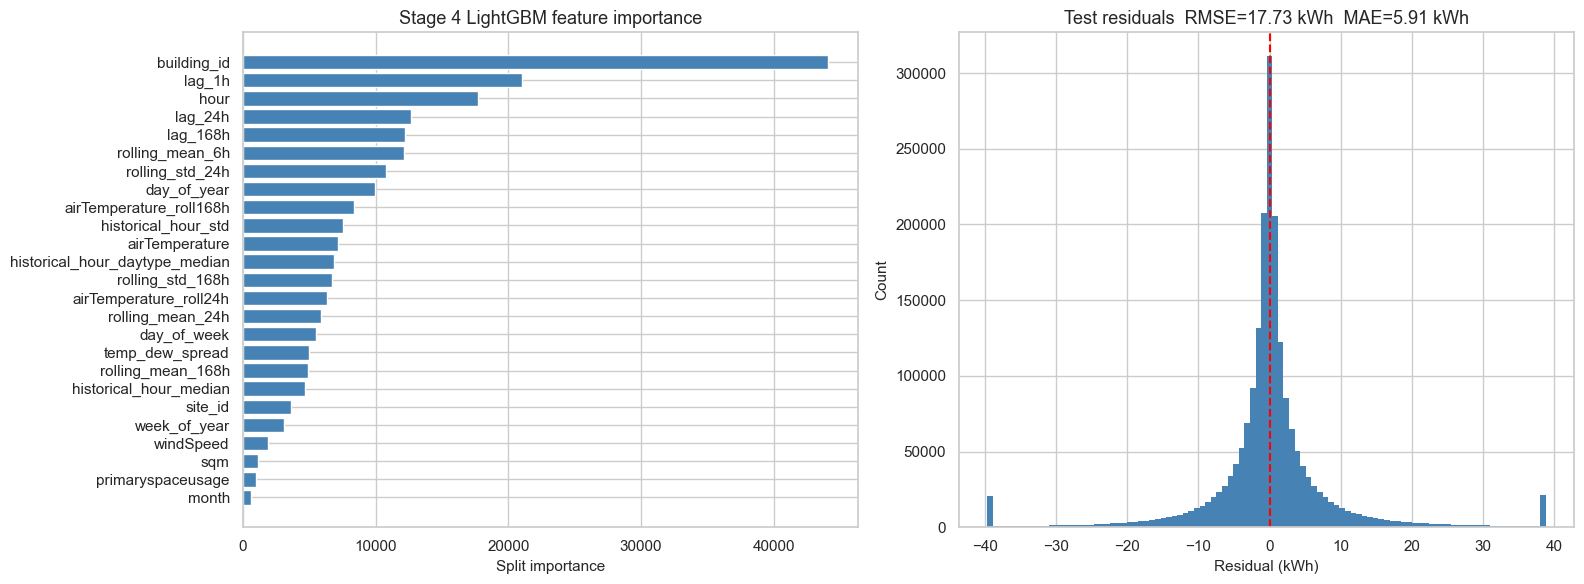

,feature,importance
0,building_id,44121
1,lag_1h,20995
2,hour,17711
3,lag_24h,12629
4,lag_168h,12229
5,rolling_mean_6h,12161
6,rolling_std_24h,10774
7,day_of_year,9941
8,airTemperature_roll168h,8379
9,historical_hour_std,7530


In [10]:
importance = (
    pd.DataFrame({
        'feature': final_model.feature_name_,
        'importance': final_model.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

resid_test = test_df[TARGET_COL].values - test_pred
lo, hi = np.percentile(resid_test, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top25 = importance.head(25)
axes[0].barh(top25['feature'][::-1], top25['importance'][::-1], color='steelblue')
axes[0].set_title('Stage 4 LightGBM feature importance')
axes[0].set_xlabel('Split importance')

axes[1].hist(np.clip(resid_test, lo, hi), bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Test residuals  RMSE={test_rmse:.2f} kWh  MAE={test_mae:.2f} kWh')
axes[1].set_xlabel('Residual (kWh)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

display(importance.head(30))

---
## 8. Residual Calibration (Out-of-Sample)

Per-building z-score stats (`resid_median`, `resid_mad`) are calibrated from `early_stop_model`
predictions on `final_valid` (Jul–Oct 2017) — a period the model **never saw during training**
(trained on Jan 2016 – Jun 2017 only).

This corrects the Stage 3 approach which calibrated on in-sample training residuals, causing the
MAD denominator to be artificially small and inflating z-scores across the scoring period.

In [15]:
ANOMALY_Z = 3.0
STAGE4B_RESID_STATS_OUT = OUTPUTS_DIR / 'stage4b_resid_stats.parquet'

# early_stop_model was trained on final_train (Jan 2016 – Jun 2017) only,
# so its predictions on final_valid (Jul–Oct 2017) are genuinely out-of-sample.
cal_pred = early_stop_model.predict(final_valid[FEATURE_COLS]).clip(min=0)
cal_resid = pd.DataFrame({
    'building_id': final_valid['building_id'].values,
    'resid': final_valid[TARGET_COL].values - cal_pred,
})

resid_stats = (
    cal_resid.groupby('building_id')['resid']
    .agg(
        resid_median='median',
        resid_mad=lambda x: np.median(np.abs(x - np.median(x))),
    )
    .reset_index()
)

# Fallback for buildings absent from the calibration window (NaN stats):
# fill using primaryspaceusage-group medians from buildings that did calibrate.
bld_meta = (
    test_df[['building_id', 'site_id', 'primaryspaceusage']]
    .drop_duplicates('building_id')
    .assign(primaryspaceusage=lambda d: d['primaryspaceusage'].astype(str))
)
resid_stats = bld_meta.merge(resid_stats, on='building_id', how='left')

nan_mask = resid_stats['resid_median'].isna()
group_fb = (
    resid_stats.loc[~nan_mask]
    .groupby('primaryspaceusage')[['resid_median', 'resid_mad']]
    .median()
    .rename(columns={'resid_median': 'fb_median', 'resid_mad': 'fb_mad'})
)
resid_stats = resid_stats.merge(group_fb, on='primaryspaceusage', how='left')
resid_stats.loc[nan_mask, 'resid_median'] = resid_stats.loc[nan_mask, 'fb_median']
resid_stats.loc[nan_mask, 'resid_mad']    = resid_stats.loc[nan_mask, 'fb_mad']
resid_stats = resid_stats.drop(columns=['fb_median', 'fb_mad'])

n_direct    = int((~nan_mask).sum())
n_fallback  = int(nan_mask.sum())
n_zero_mad  = int((resid_stats['resid_mad'] == 0).sum())
n_still_nan = int(resid_stats['resid_mad'].isna().sum())
print(f'Buildings calibrated (direct)  : {n_direct:,}')
print(f'Buildings on group fallback    : {n_fallback}')
print(f'Buildings with MAD = 0         : {n_zero_mad}  (will use MAD_FLOOR={1e-3})')
print(f'Buildings still NaN (no group) : {n_still_nan}')
print(f'\nCalibration residual summary (global):')
print(cal_resid['resid'].describe().round(3))

# Export with metadata — model file and calibration stats are an inseparable artifact pair.
resid_stats.to_parquet(STAGE4B_RESID_STATS_OUT, index=False)
print(f'\nResid stats exported → {STAGE4B_RESID_STATS_OUT}')

# Drop metadata cols so Section 9's merge doesn't create site_id_x / site_id_y conflicts.
resid_stats = resid_stats.drop(columns=['site_id', 'primaryspaceusage'])

Buildings calibrated (direct)  : 1,409
Buildings on group fallback    : 30
Buildings with MAD = 0         : 0  (will use MAD_FLOOR=0.001)
Buildings still NaN (no group) : 0

Calibration residual summary (global):
count    4132142.000
mean          -0.241
std           22.426
min        -2334.954
25%           -2.281
50%           -0.080
75%            1.974
max         2048.779
Name: resid, dtype: float64

Resid stats exported → ..\..\data\processed\anomaly-detection\stage4b_resid_stats.parquet


---
## 9. Anomaly Scoring on Test Period (Nov–Dec 2017)

The `final_model` (trained on all data before Nov 2017) predicts on the held-out test period.
Residuals are z-scored using the calibrated per-building stats from Section 8.

In [16]:
score_df = test_df.copy()
score_df['predicted'] = test_pred
score_df['residual'] = score_df[TARGET_COL].values - score_df['predicted'].values

score_df = score_df.merge(resid_stats, on='building_id', how='left')

MAD_SCALE = 1.4826
MAD_FLOOR = 1e-3
safe_mad = (score_df['resid_mad'] * MAD_SCALE).clip(lower=MAD_FLOOR)
score_df['residual_z'] = (score_df['residual'] - score_df['resid_median']) / safe_mad
score_df['anomaly_score'] = score_df['residual_z'].abs()
score_df['is_anomaly'] = score_df['anomaly_score'] > ANOMALY_Z
score_df['direction'] = np.where(
    score_df['residual_z'] >  ANOMALY_Z, 'over',
    np.where(score_df['residual_z'] < -ANOMALY_Z, 'under', 'normal'),
)

SEV_THRESHOLDS = [(10.0, 'Critical'), (6.0, 'High'), (4.0, 'Medium'), (3.0, 'Low')]
score_df['severity'] = np.select(
    [score_df['anomaly_score'] >= t for t, _ in SEV_THRESHOLDS],
    [s for _, s in SEV_THRESHOLDS],
    default='normal',
)

n_total   = len(score_df)
n_anomaly = score_df['is_anomaly'].sum()
n_over    = (score_df['direction'] == 'over').sum()
n_under   = (score_df['direction'] == 'under').sum()

print(f'Scoring rows       : {n_total:,}')
print(f'Anomalies flagged  : {n_anomaly:,}  ({n_anomaly / n_total:.2%})')
print(f'  Over-consumption : {n_over:,}  ({n_over / n_total:.2%})')
print(f'  Under-consumption: {n_under:,}  ({n_under / n_total:.2%})')

sev_order = ['Critical', 'High', 'Medium', 'Low']
print('\nSeverity breakdown:')
sev_counts = (
    score_df[score_df['is_anomaly']]['severity']
    .value_counts()
    .reindex(sev_order)
    .fillna(0)
    .astype(int)
)
for sev, cnt in sev_counts.items():
    print(f'  {sev:8s}: {cnt:,}  ({cnt / max(n_anomaly, 1):.1%})')

top_buildings = (
    score_df[score_df['is_anomaly']]
    .groupby(['building_id', 'site_id', 'primaryspaceusage'])
    .agg(
        anomaly_count=('is_anomaly',    'sum'),
        mean_z       =('anomaly_score', 'mean'),
        max_z        =('anomaly_score', 'max'),
        n_critical   =('severity', lambda x: (x == 'Critical').sum()),
        n_high       =('severity', lambda x: (x == 'High').sum()),
    )
    .sort_values('anomaly_count', ascending=False)
    .head(20)
    .reset_index()
)
print('\nTop 20 buildings by anomaly count:')
display(top_buildings)

Scoring rows       : 2,031,624
Anomalies flagged  : 124,606  (6.13%)
  Over-consumption : 68,231  (3.36%)
  Under-consumption: 56,375  (2.77%)

Severity breakdown:
  Critical: 9,450  (7.6%)
  High    : 19,109  (15.3%)
  Medium  : 40,234  (32.3%)
  Low     : 55,813  (44.8%)

Top 20 buildings by anomaly count:


,building_id,site_id,primaryspaceusage,anomaly_count,mean_z,max_z,n_critical,n_high
0,Cockatoo_assembly_Valencia,Cockatoo,Entertainment/public assembly,695,6.865107,16.078149,137.0,195.0
1,Rat_public_Kelle,Rat,Public services,642,5.725237,21.288443,44.0,181.0
2,Rat_public_Vickie,Rat,Public services,642,8.110469,75.388140,154.0,202.0
3,Gator_assembly_Stacy,Gator,Entertainment/public assembly,611,6.199139,64.480772,47.0,203.0
4,Hog_office_Catalina,Hog,Office,596,7.556862,61.703822,100.0,159.0
5,Rat_assembly_Jannie,Rat,Entertainment/public assembly,593,10.132975,62.002363,185.0,83.0
6,Lamb_assembly_Dillon,Lamb,Entertainment/public assembly,567,6.792482,34.750650,69.0,170.0
7,Gator_assembly_Maurine,Gator,Entertainment/public assembly,563,7.982133,76.870974,100.0,136.0
8,Rat_assembly_Teddy,Rat,Entertainment/public assembly,555,5.533811,11.929568,6.0,189.0
9,Rat_education_Leonardo,Rat,Education,553,6.015315,23.525341,57.0,132.0


---
## 10. Export

In [17]:
STAGE4B_ANOMALIES_OUT = OUTPUTS_DIR / 'stage4b_anomalies.parquet'

keep_cols = ['building_id', 'timestamp', TARGET_COL, 'predicted', 'residual',
             'residual_z', 'anomaly_score', 'severity', 'direction', 'is_anomaly']
for extra in ['site_id', 'primaryspaceusage', 'sqm']:
    if extra in score_df.columns:
        keep_cols.append(extra)

out_df = score_df[keep_cols].copy()
out_df.to_parquet(STAGE4B_ANOMALIES_OUT, index=False)

print(f'Exported → {STAGE4B_ANOMALIES_OUT}')
print(f'Rows     : {len(out_df):,}')
print(f'Anomalies: {out_df["is_anomaly"].sum():,}  ({out_df["is_anomaly"].mean():.2%})')

sev_order = ['Critical', 'High', 'Medium', 'Low']
sev_counts = (
    out_df[out_df['is_anomaly']]['severity']
    .value_counts()
    .reindex(sev_order)
    .fillna(0)
    .astype(int)
)
for sev, cnt in sev_counts.items():
    print(f'  {sev:8s}: {cnt:,}')

Exported → ..\..\data\processed\anomaly-detection\stage4b_anomalies.parquet
Rows     : 2,031,624
Anomalies: 124,606  (6.13%)
  Critical: 9,450
  High    : 19,109
  Medium  : 40,234
  Low     : 55,813
